In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# Set plotting defaults
plt.rcParams['figure.figsize'] = (10, 8)

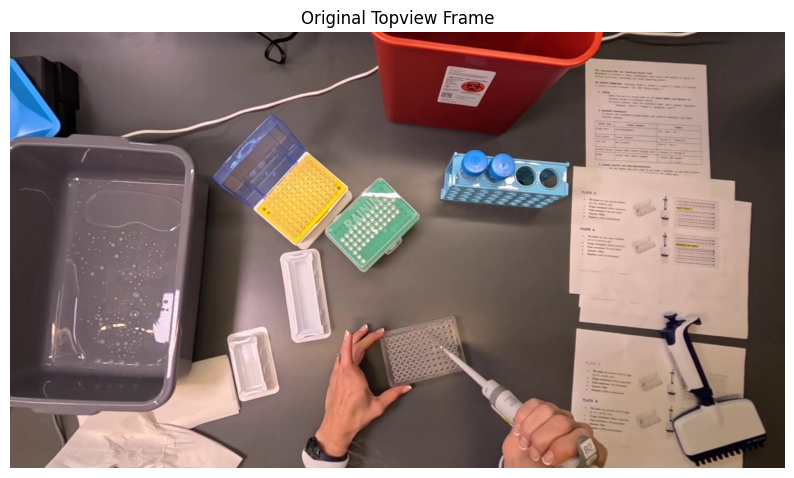

In [14]:
# Select a test video
video_path = '../data/pipette_well_dataset/Plate_10_clip_0001_TopView.mp4'

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    # OpenCV loads images in BGR, matplotlib expects RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    plt.imshow(frame_rgb)
    plt.title("Original Topview Frame")
    plt.axis('off')
    plt.show()
else:
    print("Failed to load video. Check the file path.")

Found 30 circles. (Target: 96)


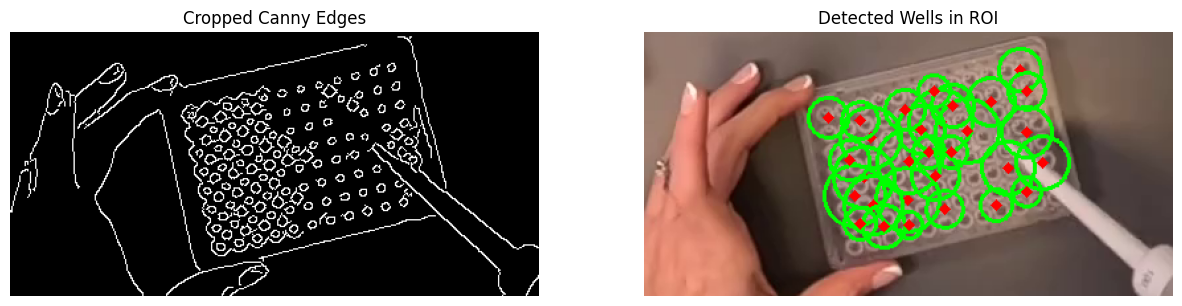

In [18]:
# --- 1. Define the Region of Interest (ROI) ---
# We are slicing the numpy array to only look at the bottom-center of the table.
# You will need to tweak these exact numbers based on the frame dimensions!
# Format: frame[y_start:y_end, x_start:x_end]
roi_y1, roi_y2 = 700, 900  # Roughly the bottom half of a 1080p video
roi_x1, roi_x2 = 800, 1200  # Roughly the center-right 

# Crop the original frame
cropped_frame = frame_rgb[roi_y1:roi_y2, roi_x1:roi_x2].copy()

# --- 2. Preprocessing on the CROPPED frame ---
gray = cv2.cvtColor(cropped_frame, cv2.COLOR_RGB2GRAY)
blurred = cv2.medianBlur(gray, 5) 
edges = cv2.Canny(blurred, 50, 150)

# --- 3. Tweak Parameters for the smaller, cropped area ---
# Because we are looking at a cropped area, you can likely afford to lower param2 
# slightly without picking up the trash can or paper text.
min_dist = 15       
param1 = 50         
param2 = 25         
min_radius = 8      
max_radius = 25     

circles = cv2.HoughCircles(
    blurred, 
    cv2.HOUGH_GRADIENT, 
    dp=1.2, 
    minDist=min_dist,
    param1=param1, 
    param2=param2, 
    minRadius=min_radius, 
    maxRadius=max_radius
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        # Draw the circles on the CROPPED frame
        cv2.circle(cropped_frame, (i[0], i[1]), i[2], (0, 255, 0), 2)
        cv2.circle(cropped_frame, (i[0], i[1]), 2, (255, 0, 0), 3)
        
    print(f"Found {len(circles[0])} circles. (Target: 96)")
else:
    print("No circles found. Try lowering param2.")

# --- 4. Display ---
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].imshow(edges, cmap='gray')
axes[0].set_title("Cropped Canny Edges")
axes[0].axis('off')

axes[1].imshow(cropped_frame)
axes[1].set_title("Detected Wells in ROI")
axes[1].axis('off')

plt.show()

Found a 4-corner plate contour!


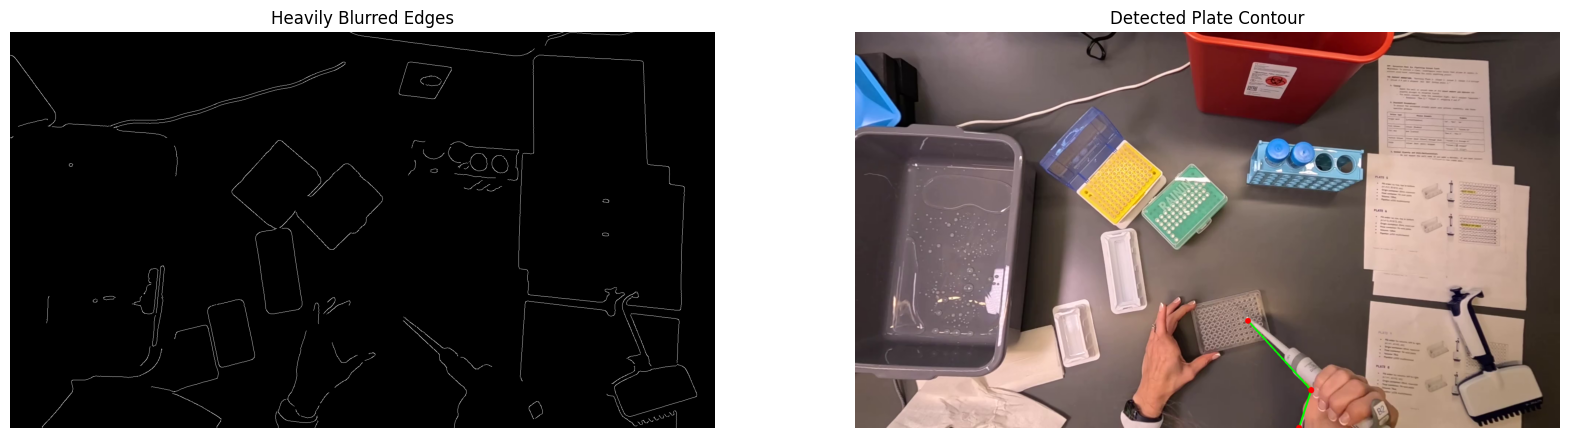

In [19]:
# 1. Heavy blur to eliminate the noise of the wells and water
gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
heavy_blur = cv2.GaussianBlur(gray, (21, 21), 0)

# 2. Edge detection on the blurred image
edges = cv2.Canny(heavy_blur, 30, 100)

# 3. Find Contours
# RETR_EXTERNAL ensures we only get the outermost boundaries, ignoring anything inside
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 4. Sort contours by area, keep the largest ones
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

output_frame = frame_rgb.copy()
plate_contour = None

for c in contours:
    # Approximate the contour to a polygon
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    
    # If the polygon has 4 vertices, we can assume it's our rectangular plate
    if len(approx) == 4:
        plate_contour = approx
        break

# 5. Draw the result
if plate_contour is not None:
    cv2.drawContours(output_frame, [plate_contour], -1, (0, 255, 0), 4)
    
    # Draw the 4 corners in red
    for point in plate_contour:
        x, y = point[0]
        cv2.circle(output_frame, (x, y), 8, (255, 0, 0), -1)
    print("Found a 4-corner plate contour!")
else:
    # If it couldn't find a perfect 4-corner shape, draw the largest general contour
    cv2.drawContours(output_frame, [contours[0]], -1, (255, 255, 0), 4)
    print("Could not find a 4-corner shape. Drawing largest object instead.")

# Display
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(edges, cmap='gray')
axes[0].set_title("Heavily Blurred Edges")
axes[0].axis('off')

axes[1].imshow(output_frame)
axes[1].set_title("Detected Plate Contour")
axes[1].axis('off')

plt.show()

Could not find a matching plate contour.


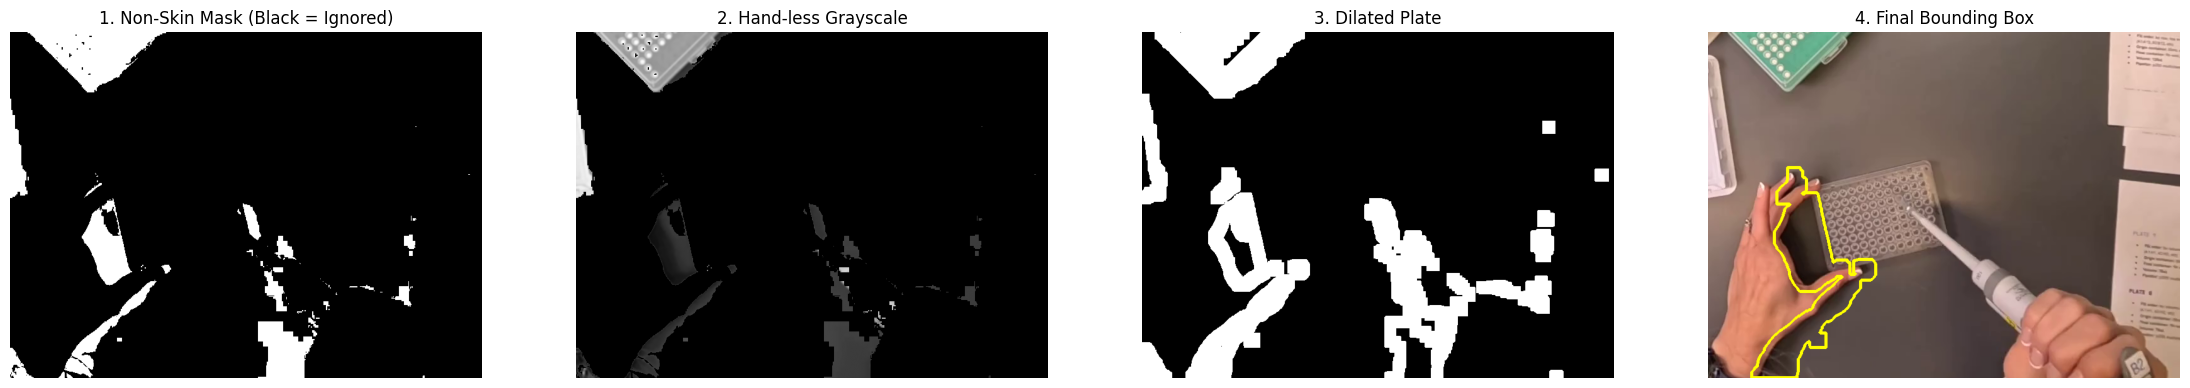

In [21]:
# --- 1. Shifted ROI (Moved right to ignore the empty tray completely) ---
roi_y1, roi_y2 = 500, 1050  
roi_x1, roi_x2 = 750, 1500  
cropped_frame = frame_rgb[roi_y1:roi_y2, roi_x1:roi_x2].copy()

# --- 2. HSV Skin Masking (Erase the hands) ---
# Convert to HSV color space for easier color targeting
hsv = cv2.cvtColor(cropped_frame, cv2.COLOR_RGB2HSV)

# Define a rough range for human skin tones in HSV
lower_skin = np.array([0, 20, 70], dtype=np.uint8)
upper_skin = np.array([20, 255, 255], dtype=np.uint8)

# Create a mask where skin is white (255) and everything else is black (0)
skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

# Invert the mask: Skin becomes black (ignored), everything else is white (kept)
non_skin_mask = cv2.bitwise_not(skin_mask)

# --- 3. Edge Detection on the Masked Image ---
gray = cv2.cvtColor(cropped_frame, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply the non-skin mask to the blurred image BEFORE edge detection
# This effectively deletes the hands from the frame
gray_masked = cv2.bitwise_and(blurred, blurred, mask=non_skin_mask)

# Find edges on the hand-less image
edges = cv2.Canny(gray_masked, 40, 120)

# --- 4. Morphological Dilation ---
# Using a slightly smaller kernel so things don't bleed too far
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 10))
dilated = cv2.dilate(edges, kernel, iterations=2)

# --- 5. Find and Filter Contours ---
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

plate_contour = None
output_frame = cropped_frame.copy()

for c in contours:
    area = cv2.contourArea(c)
    if area > 8000: # Needs to be a large object
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.05 * peri, True)
        
        # Check if it has 4 corners
        if len(approx) == 4:
            # --- ASPECT RATIO CHECK ---
            # Get the bounding box of the contour
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            
            # A 96-well plate is ~1.5 ratio. Allow some perspective distortion (1.2 to 1.8)
            if 1.2 <= aspect_ratio <= 1.8:
                plate_contour = approx
                break

# --- 6. Draw Results ---
if plate_contour is not None:
    cv2.drawContours(output_frame, [plate_contour], -1, (0, 255, 0), 4)
    for point in plate_contour:
        px, py = point[0]
        cv2.circle(output_frame, (px, py), 8, (255, 0, 0), -1)
    print("Success! Found the 96-well plate!")
else:
    if len(contours) > 0:
        cv2.drawContours(output_frame, [contours[0]], -1, (255, 255, 0), 4)
    print("Could not find a matching plate contour.")

# Display
fig, axes = plt.subplots(1, 4, figsize=(28, 7))

axes[0].imshow(non_skin_mask, cmap='gray')
axes[0].set_title("1. Non-Skin Mask (Black = Ignored)")
axes[0].axis('off')

axes[1].imshow(gray_masked, cmap='gray')
axes[1].set_title("2. Hand-less Grayscale")
axes[1].axis('off')

axes[2].imshow(dilated, cmap='gray')
axes[2].set_title("3. Dilated Plate")
axes[2].axis('off')

axes[3].imshow(output_frame)
axes[3].set_title("4. Final Bounding Box")
axes[3].axis('off')

plt.show()

Detected 33 raw wells. Filtered down to 32 valid wells.


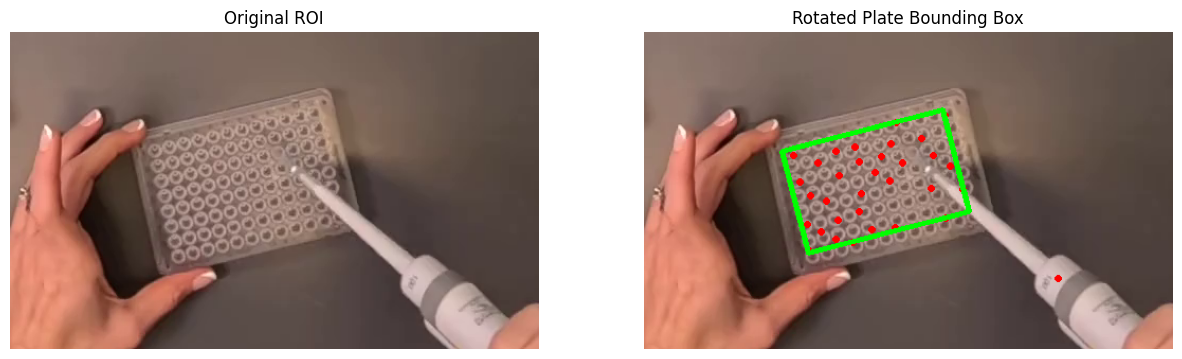

In [25]:
# --- 1. Define ROI ---
roi_y1, roi_y2 = 650, 950  
roi_x1, roi_x2 = 800, 1300  
cropped_frame = frame_rgb[roi_y1:roi_y2, roi_x1:roi_x2].copy()

# --- 2. Preprocessing & Hough Circles ---
gray = cv2.cvtColor(cropped_frame, cv2.COLOR_RGB2GRAY)
blurred = cv2.medianBlur(gray, 5) 

circles = cv2.HoughCircles(
    blurred, 
    cv2.HOUGH_GRADIENT, 
    dp=1.2, 
    minDist=15,
    param1=50, 
    param2=25, 
    minRadius=8, 
    maxRadius=25
)

output_frame = cropped_frame.copy()
plate_corners = None

if circles is not None:
    circles = np.uint16(np.around(circles))
    
    # Extract points
    points = []
    for i in circles[0, :]:
        points.append([i[0], i[1]])
        # Draw all raw detected circles in faint red
        cv2.circle(output_frame, (i[0], i[1]), 2, (255, 0, 0), 2)
        
    points = np.array(points)
    
    # --- 3. Outlier Rejection (Ignore the Pipette) ---
    # Find the median center of the cluster
    median_x = np.median(points[:, 0])
    median_y = np.median(points[:, 1])
    
    valid_points = []
    for pt in points:
        # Calculate distance from the median center
        dist = np.sqrt((pt[0] - median_x)**2 + (pt[1] - median_y)**2)
        # If a point is further than ~180 pixels, it's likely the pipette or garbage
        if dist < 180: 
            valid_points.append(pt)
            
    valid_points = np.array(valid_points, dtype=np.float32)
    
    # --- 4. Rotated Bounding Box ---
    # minAreaRect finds the tightest fitting rotated rectangle around our valid points
    rect = cv2.minAreaRect(valid_points)
    
    # Get the 4 corners of the rotated rectangle
    box = cv2.boxPoints(rect)
    plate_corners = np.int32(box) 
    
    # Draw the rotated box in thick green
    cv2.drawContours(output_frame, [plate_corners], 0, (0, 255, 0), 3)
    
    print(f"Detected {len(points)} raw wells. Filtered down to {len(valid_points)} valid wells.")
else:
    print("Failed to detect any wells.")

# --- 5. Display ---
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(cropped_frame)
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(output_frame)
axes[1].set_title("Rotated Plate Bounding Box")
axes[1].axis('off')

plt.show()

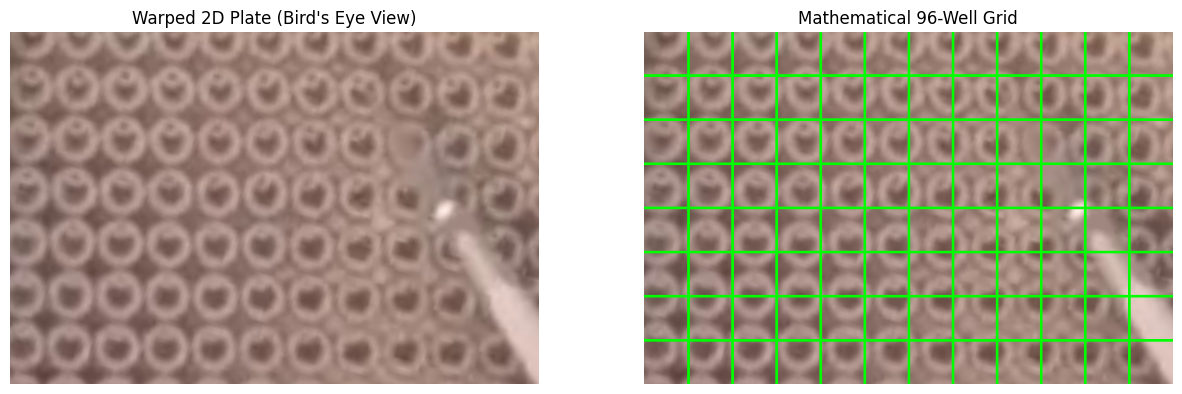

In [26]:
# --- 1. Helper Function to Order Corners ---
def order_points(pts):
    # Initialize a list of coordinates that will be ordered
    # such that the first entry in the list is the top-left,
    # the second entry is the top-right, the third is the
    # bottom-right, and the fourth is the bottom-left
    rect = np.zeros((4, 2), dtype="float32")

    # the top-left point will have the smallest sum, whereas
    # the bottom-right point will have the largest sum
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    # now, compute the difference between the points, the
    # top-right point will have the smallest difference,
    # whereas the bottom-left will have the largest difference
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect

# --- 2. Calculate the Homography Matrix ---
# Order our previously found green box corners
src_pts = order_points(plate_corners)

# Define the dimensions of our "Perfect 2D Plate"
# A standard plate is a 3:2 ratio. 600x400 gives us perfect 50x50 pixel wells.
max_width = 600
max_height = 400

# Define the destination points (a perfect 0,0 to 600,400 rectangle)
dst_pts = np.array([
    [0, 0],
    [max_width - 1, 0],
    [max_width - 1, max_height - 1],
    [0, max_height - 1]
], dtype="float32")

# Calculate the perspective transform matrix
M = cv2.getPerspectiveTransform(src_pts, dst_pts)

# --- 3. Apply the Warp ---
# Warp the cropped frame using the matrix M
warped_plate = cv2.warpPerspective(cropped_frame, M, (max_width, max_height))

# --- 4. Draw the 96-Well Grid ---
output_grid = warped_plate.copy()
wells_cols = 12
wells_rows = 8
cell_w = max_width // wells_cols
cell_h = max_height // wells_rows

# Draw vertical lines (Columns 1-12)
for i in range(1, wells_cols):
    x = i * cell_w
    cv2.line(output_grid, (x, 0), (x, max_height), (0, 255, 0), 2)

# Draw horizontal lines (Rows A-H)
for i in range(1, wells_rows):
    y = i * cell_h
    cv2.line(output_grid, (0, y), (max_width, y), (0, 255, 0), 2)

# --- 5. Display the Magic ---
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(warped_plate)
axes[0].set_title("Warped 2D Plate (Bird's Eye View)")
axes[0].axis('off')

axes[1].imshow(output_grid)
axes[1].set_title("Mathematical 96-Well Grid")
axes[1].axis('off')

plt.show()